In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
import hdbscan
import umap
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import zscore

Dataset: <br>
League - All <br>
Year(s) - 2021-25 <br>

In [2]:
# --- 1. DATA PREPARATION ---
df = pd.read_csv('../data/v2/Final_DataSet_All_Fixed.csv')

# Determine Final Outcomes
filtered_ft = df.loc[df['Time'] == 'FT'].copy()
conditions = [
    (filtered_ft['Home_Score'] > filtered_ft['Away_Score']),
    (filtered_ft['Away_Score'] > filtered_ft['Home_Score']),
    (filtered_ft['Home_Score'] == filtered_ft['Away_Score'])
]
choices = ['Home_Win', 'Away_Win', 'Draw']
filtered_ft['Match_Outcomes'] = np.select(conditions, choices, default='Unknown')
outcome_map = dict(zip(filtered_ft['Game_ID'], filtered_ft['Match_Outcomes']))
df['Match_Outcomes'] = df['Game_ID'].map(outcome_map)

# Preprocessing
df_mod = df[(df['Time'] != 'FT') & (df['Matchweek'] != 'Cup')].copy()
df_mod['Time'] = df_mod['Time'].apply(eval)

# --- 5-MINUTE TIME BINNING ---
df_mod['Time_Bin'] = (df_mod['Time'] // 5).astype(int)

df_mod['Score_Diff'] = df_mod['Home_Score'] - df_mod['Away_Score']
df_mod['Home_Score_Log'] = np.log1p(df_mod['Home_Score'])
df_mod['Away_Score_Log'] = np.log1p(df_mod['Away_Score'])

features = ['Time_Bin', 'Score_Diff', 'Home_Score_Log', 'Away_Score_Log', 
            'Home_Red_Count', 'Away_Red_Count', 'Home_Off_Sub_Count', 'Away_Off_Sub_Count']
X = df_mod[features].fillna(0)
y_true = df_mod['Match_Outcomes']

# Scaling with Jitter
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X + np.random.normal(0, 1e-5, X.shape))

--- Stage 1: Running Baseline ---


C:\Users\matth\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


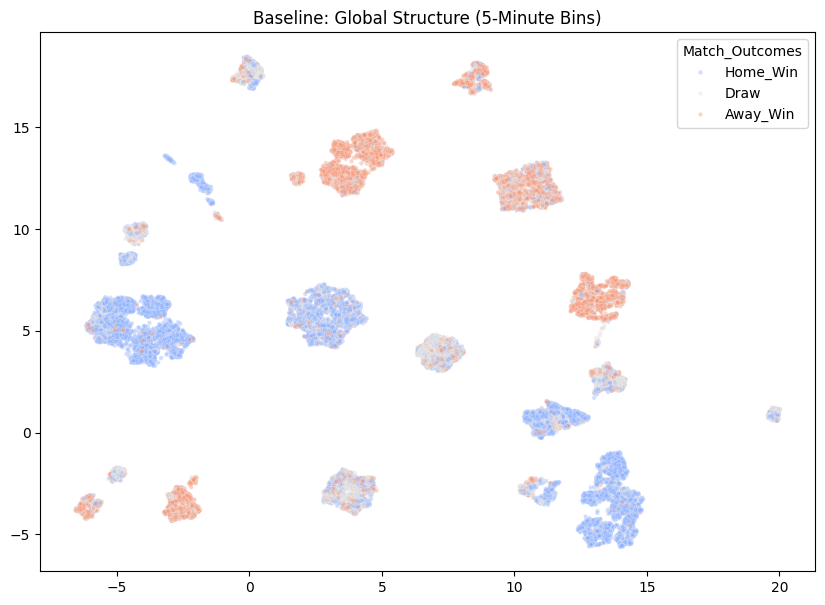


REASONING FOR NEXT STEP:
Stage 1 identifies the raw topological groups. We move to Stage 2 to use
supervised dimensionality reduction, forcing these groups into outcome-specific islands.


In [14]:
# STAGE 1: BASELINE (Global Structure)
# =================================================================
print("--- Stage 1: Running Baseline ---")
reducer_base = umap.UMAP(n_neighbors=30, min_dist=0.1, metric='canberra', init='random', random_state=42)
X_umap_base = reducer_base.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_umap_base[:, 0], y=X_umap_base[:, 1], hue=y_true, s=10, alpha=0.4, palette='coolwarm')
plt.title("Baseline: Global Structure (5-Minute Bins)")
plt.show()

print("\nREASONING FOR NEXT STEP:")
print("Stage 1 identifies the raw topological groups. We move to Stage 2 to use")
print("supervised dimensionality reduction, forcing these groups into outcome-specific islands.")


--- Stage 2: Supervised 2D & 3D UMAP + HDBSCAN ---


C:\Users\matth\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\matth\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


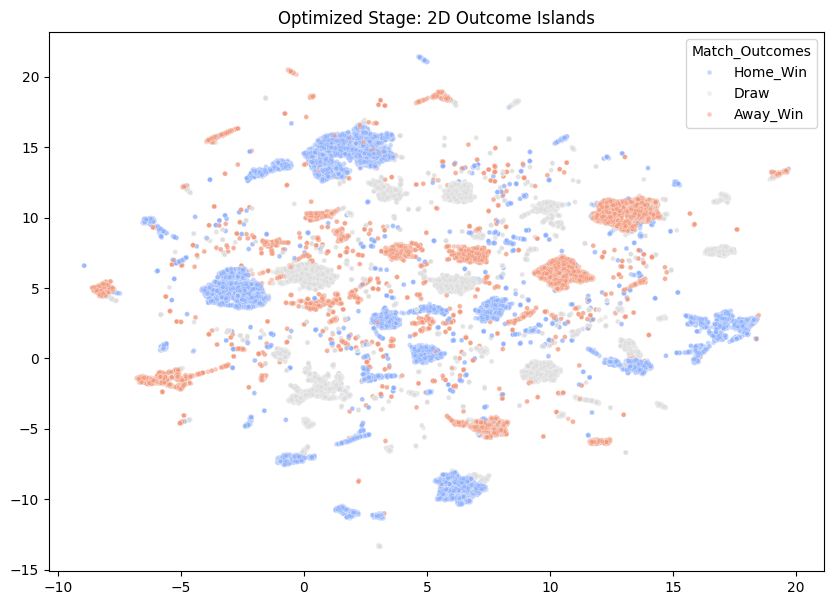

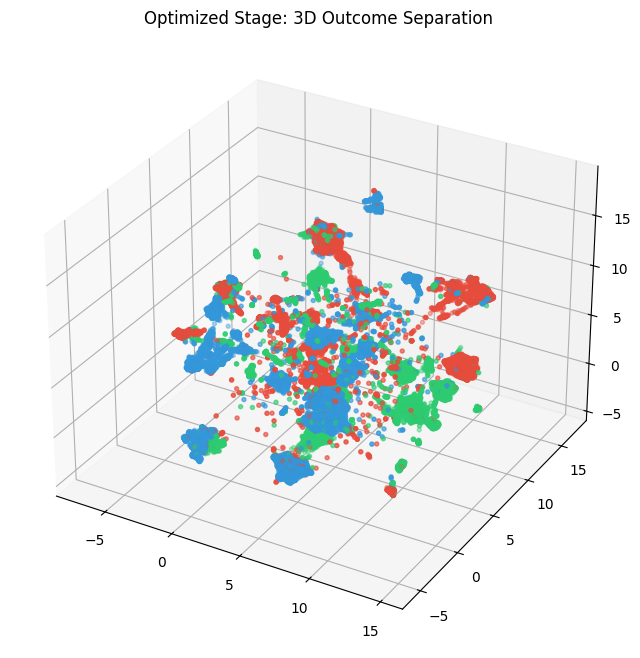

In [4]:
# STAGE 2: OPTIMIZED (2D & 3D Supervised Separation)
# =================================================================
print("\n--- Stage 2: Supervised 2D & 3D UMAP + HDBSCAN ---")

y_encoded, _ = pd.factorize(y_true)

reducer_2d = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, target_weight=0.9, metric='canberra', init='random', random_state=42)
X_umap_2d = reducer_2d.fit_transform(X_scaled, y=y_encoded)

reducer_3d = umap.UMAP(n_components=3, n_neighbors=15, min_dist=0.2, target_weight=0.9, metric='canberra', init='random', random_state=42)
X_umap_3d = reducer_3d.fit_transform(X_scaled, y=y_encoded)

clusterer_opt = hdbscan.HDBSCAN(min_cluster_size=60, min_samples=10)
labels_opt = clusterer_opt.fit_predict(X_umap_3d)

# 2D Plot
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_umap_2d[:, 0], y=X_umap_2d[:, 1], hue=y_true, s=12, alpha=0.5, palette='coolwarm')
plt.title("Optimized Stage: 2D Outcome Islands")
plt.show()

# 3D Plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
color_map_3d = {'Home_Win': '#3498db', 'Away_Win': '#e74c3c', 'Draw': '#2ecc71'}
colors = [color_map_3d[val] for val in y_true]
ax.scatter(X_umap_3d[:, 0], X_umap_3d[:, 1], X_umap_3d[:, 2], c=colors, s=8, alpha=0.4)
ax.set_title("Optimized Stage: 3D Outcome Separation")
plt.show()


--- Stage 3: Outcome-Specific Archetype Analysis ---


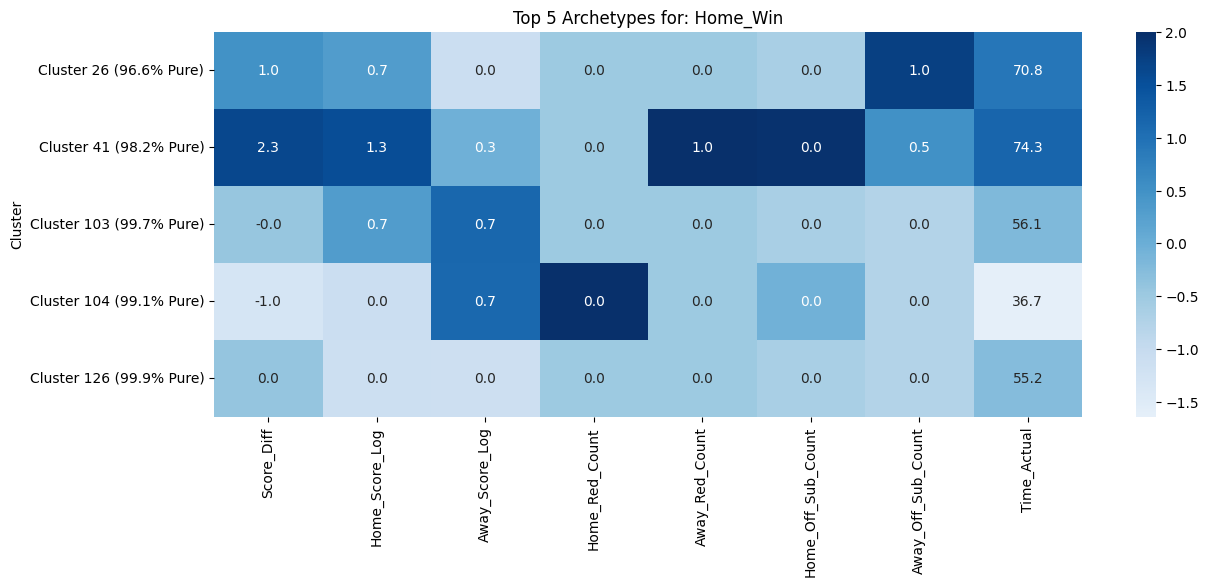

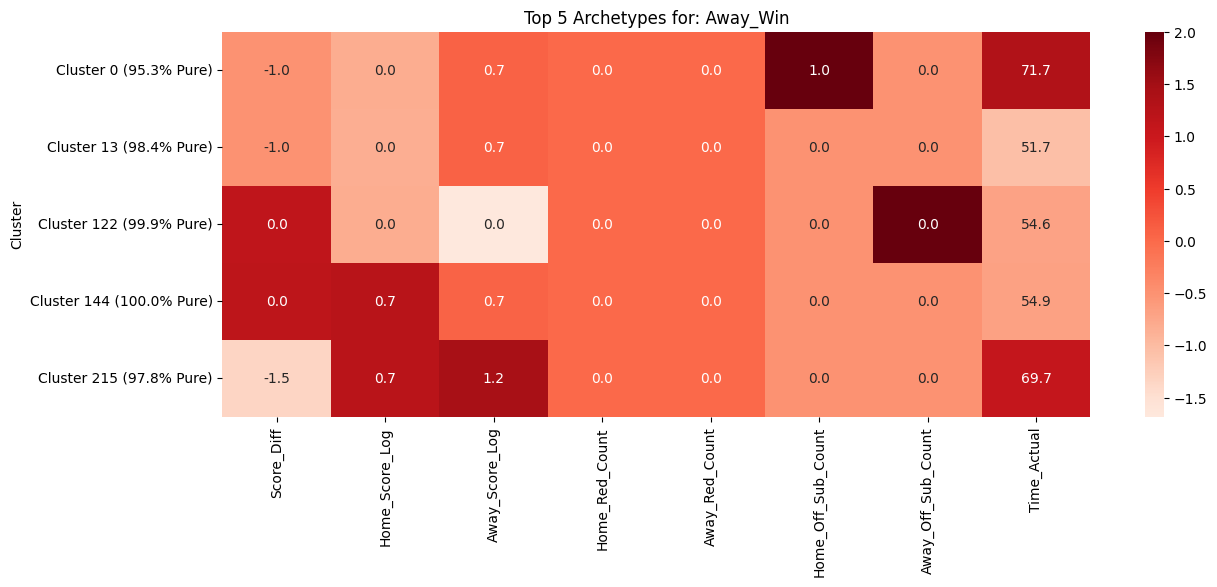

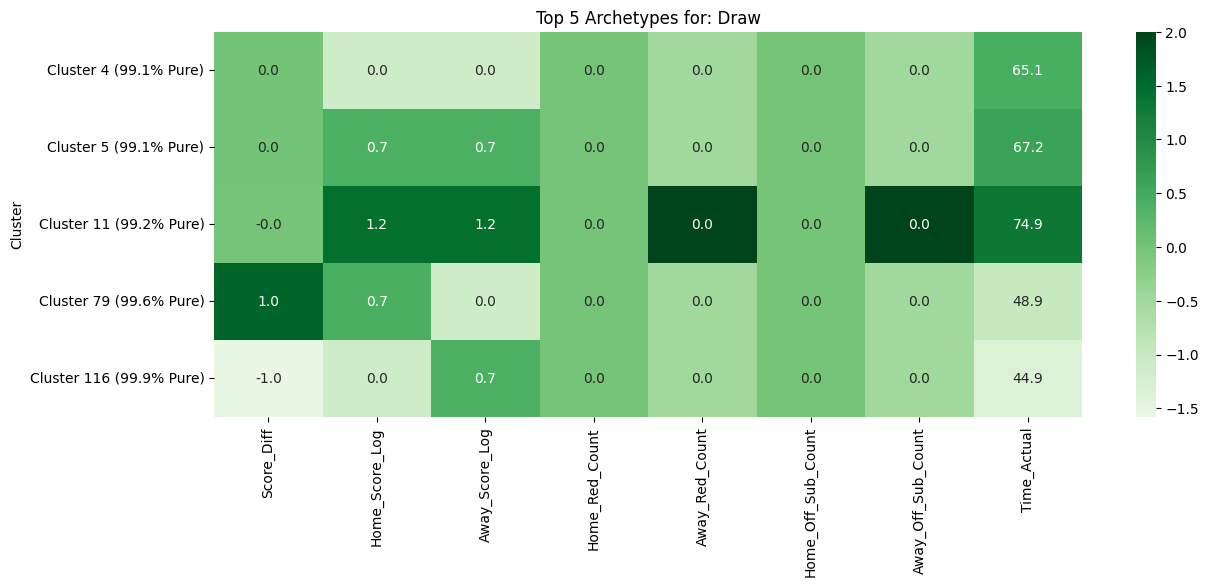

In [5]:
# STAGE 3: OUTCOME-SPECIFIC ARCHETYPES
# =================================================================
print("\n--- Stage 3: Outcome-Specific Archetype Analysis ---")

analysis_df = X.copy()
analysis_df['Cluster'] = labels_opt
analysis_df['Outcome'] = y_true.values
analysis_df['Time_Actual'] = df_mod['Time'].values

purity = pd.crosstab(analysis_df['Cluster'], analysis_df['Outcome'], normalize='index')
dominant_outcome = purity.idxmax(axis=1)

# Store identified pure clusters for Stage 4
identified_clusters = []

def plot_outcome_heatmaps(target_outcome, color_map_name):
    relevant_clusters = purity.index[(dominant_outcome == target_outcome) & (purity.index != -1)]
    top_ids = analysis_df[analysis_df['Cluster'].isin(relevant_clusters)]['Cluster'].value_counts().iloc[:5].index
    identified_clusters.extend(top_ids)
    
    if len(top_ids) > 0:
        stats = analysis_df[analysis_df['Cluster'].isin(top_ids)].groupby('Cluster').mean(numeric_only=True)
        stats = stats.drop(columns=['Time_Bin'])
        
        z_stats = stats.apply(zscore).fillna(0)
        labels = [f"Cluster {idx} ({purity.loc[idx, target_outcome]*100:.1f}% Pure)" for idx in stats.index]
        
        plt.figure(figsize=(14, 5))
        sns.heatmap(z_stats, annot=stats, fmt=".1f", cmap=color_map_name, center=0, yticklabels=labels)
        plt.title(f"Top 5 Archetypes for: {target_outcome}")
        plt.show()

plot_outcome_heatmaps('Home_Win', 'Blues')
plot_outcome_heatmaps('Away_Win', 'Reds')
plot_outcome_heatmaps('Draw', 'Greens')


--- Stage 4: Mapping Archetypes to 2D Space ---


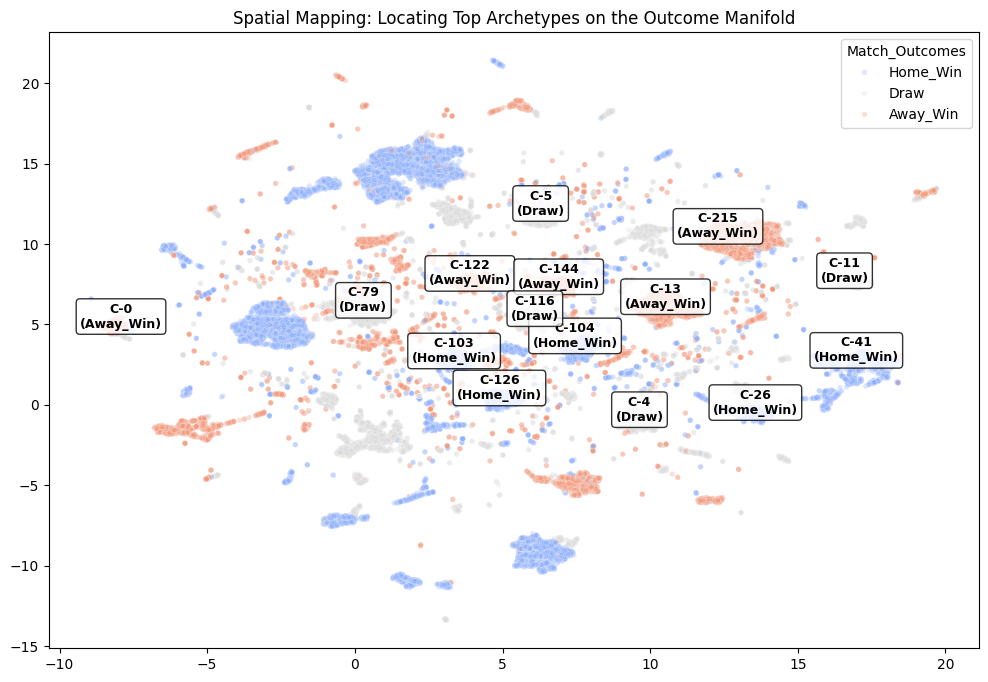


FINAL ANALYSIS:
Stage 4 connects the statistical signatures from Stage 3 back to the spatial islands.
By labeling the centroids of the top clusters, we can see exactly where high-purity
match states reside. For example, 'Draw' archetypes typically cluster in the overlap
zones between Home and Away win islands, visually representing the 'stalemate' state.


In [6]:
# STAGE 4: SPATIAL CLUSTER IDENTIFICATION
# =================================================================
print("\n--- Stage 4: Mapping Archetypes to 2D Space ---")

plt.figure(figsize=(12, 8))
# Base plot of the 2D islands
sns.scatterplot(x=X_umap_2d[:, 0], y=X_umap_2d[:, 1], hue=y_true, s=15, alpha=0.3, palette='coolwarm', legend=True)

# Annotate only the clusters identified in Stage 3
for cluster_id in set(identified_clusters):
    mask = (labels_opt == cluster_id)
    if mask.any():
        centroid_x = X_umap_2d[mask, 0].mean()
        centroid_y = X_umap_2d[mask, 1].mean()
        
        # Outcome label for the box
        outcome = dominant_outcome[cluster_id]
        
        plt.text(centroid_x, centroid_y, f"C-{cluster_id}\n({outcome})", 
                 fontsize=9, fontweight='bold', ha='center',
                 bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', boxstyle='round,pad=0.3'))

plt.title("Spatial Mapping: Locating Top Archetypes on the Outcome Manifold")
plt.show()

print("\nFINAL ANALYSIS:")
print("Stage 4 connects the statistical signatures from Stage 3 back to the spatial islands.")
print("By labeling the centroids of the top clusters, we can see exactly where high-purity")
print("match states reside. For example, 'Draw' archetypes typically cluster in the overlap")
print("zones between Home and Away win islands, visually representing the 'stalemate' state.")


--- Stage 4: Mapping Archetypes to 2D Space ---


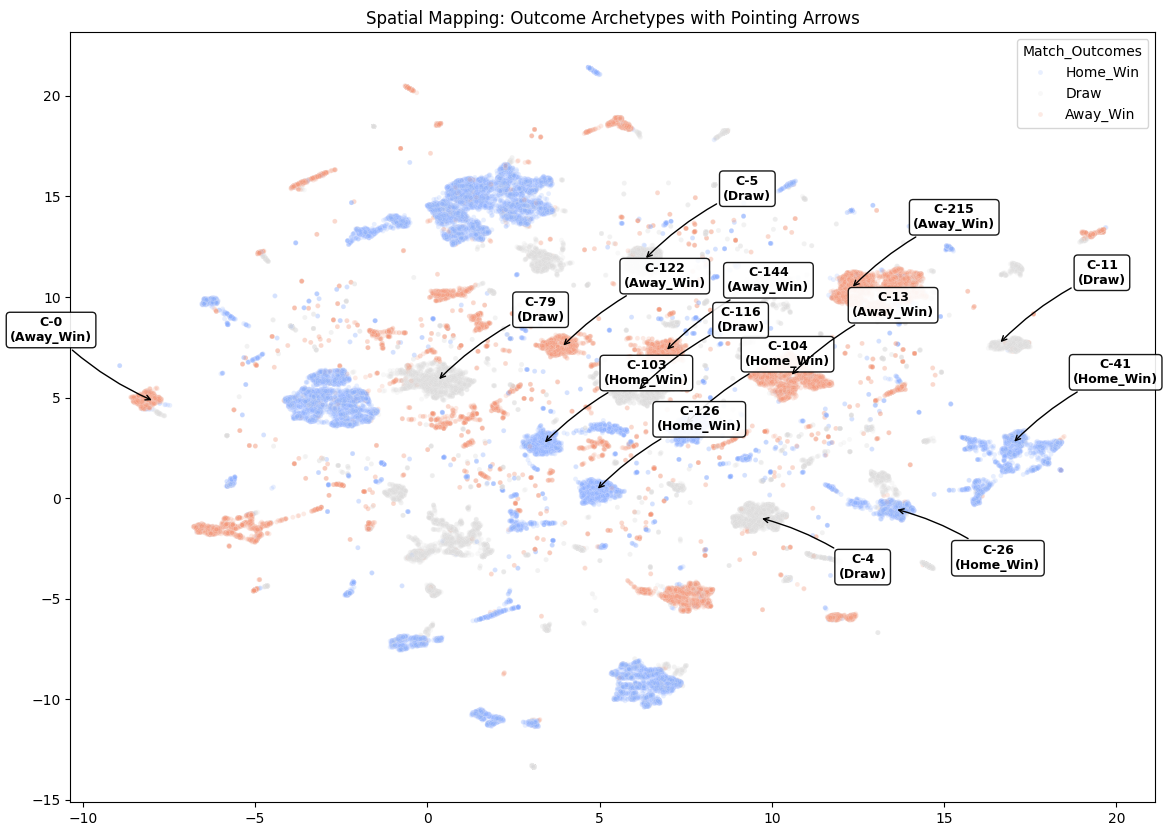


FINAL ANALYSIS:
By using leader lines (arrows), we can now clearly see the density of the islands
without the text boxes obscuring the data. This reveals how 'Draw' clusters (green)
often act as bridges or buffer zones between the Win and Loss continents.


In [7]:
# STAGE 4: SPATIAL CLUSTER IDENTIFICATION (WITH ARROWS)
# =================================================================
print("\n--- Stage 4: Mapping Archetypes to 2D Space ---")

plt.figure(figsize=(14, 10))
# Base plot of the 2D islands with lower alpha for better label contrast
sns.scatterplot(x=X_umap_2d[:, 0], y=X_umap_2d[:, 1], hue=y_true, s=12, alpha=0.2, palette='coolwarm', legend=True)

# Annotate only the clusters identified in Stage 3
for cluster_id in set(identified_clusters):
    mask = (labels_opt == cluster_id)
    if mask.any():
        centroid_x = X_umap_2d[mask, 0].mean()
        centroid_y = X_umap_2d[mask, 1].mean()
        outcome = dominant_outcome[cluster_id]
        
        # Define the offset for the label box
        # We push labels away from the center based on their position
        off_x = 3 if centroid_x > 0 else -3
        off_y = 3 if centroid_y > 0 else -3

        plt.annotate(
            f"C-{cluster_id}\n({outcome})",
            xy=(centroid_x, centroid_y),       # Point to point to
            xytext=(centroid_x + off_x, centroid_y + off_y), # Where to put text
            fontsize=9,
            fontweight='bold',
            ha='center',
            bbox=dict(facecolor='white', alpha=0.9, edgecolor='black', boxstyle='round,pad=0.3'),
            arrowprops=dict(
                arrowstyle="->",
                connectionstyle="arc3,rad=0.1", # Slightly curved lines for better aesthetics
                color='black',
                lw=1
            )
        )

plt.title("Spatial Mapping: Outcome Archetypes with Pointing Arrows")
plt.grid(False) # Clean look
plt.show()

print("\nFINAL ANALYSIS:")
print("By using leader lines (arrows), we can now clearly see the density of the islands")
print("without the text boxes obscuring the data. This reveals how 'Draw' clusters (green)")
print("often act as bridges or buffer zones between the Win and Loss continents.")


--- Stage 4: Mapping Archetypes to 2D Space ---


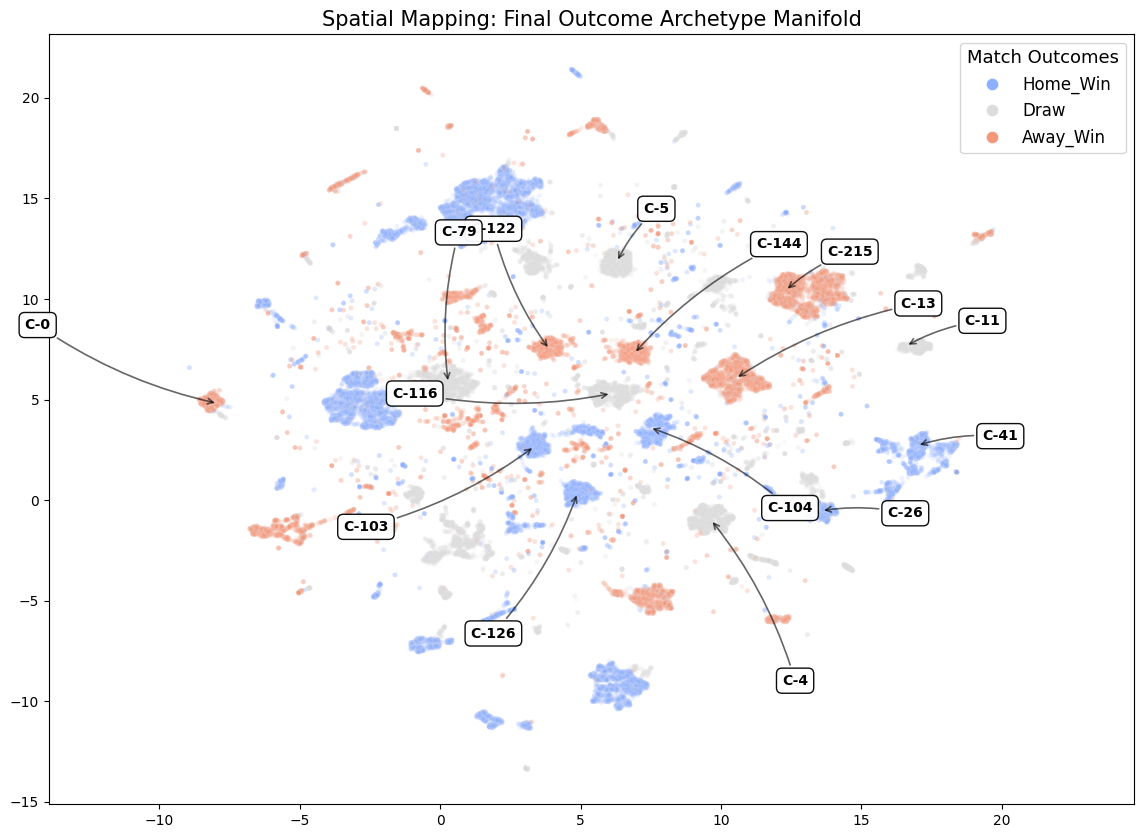


FINAL ANALYSIS:
The spatial map is now fully optimized. C-122 has been cleared of overlaps,
and the high-contrast legend allows for immediate outcome identification.
The 'islands' are now perfectly labeled as the building blocks of your k-NN model.


In [13]:
# STAGE 4: SPATIAL CLUSTER IDENTIFICATION (FINAL OPTIMIZATION)
# =================================================================
print("\n--- Stage 4: Mapping Archetypes to 2D Space ---")

plt.figure(figsize=(14, 10))
# Data points remain faint (alpha=0.15) to act as a background "map"
sns.scatterplot(x=X_umap_2d[:, 0], y=X_umap_2d[:, 1], hue=y_true, s=12, alpha=0.15, palette='coolwarm')

# Refined overrides to clear all label collisions
overrides = {
    116: [-7, 0],   
    103: [-6, -4],  
    104: [5, -4],   
    126: [-3, -7],  
    122: [-2, 6],   # Pushed Up and Left to clear C-144/C-5 area
    4:   [3, -8],   
}

for i, cluster_id in enumerate(set(identified_clusters)):
    mask = (labels_opt == cluster_id)
    if mask.any():
        centroid_x = X_umap_2d[mask, 0].mean()
        centroid_y = X_umap_2d[mask, 1].mean()
        
        dist_from_center = np.sqrt(centroid_x**2 + centroid_y**2)
        
        if cluster_id in overrides:
            off_x, off_y = overrides[cluster_id]
            text_x, text_y = centroid_x + off_x, centroid_y + off_y
        else:
            angle = np.arctan2(centroid_y, centroid_x)
            # Peripheral clusters stay close to their islands; central clusters reach out
            push = 3.0 if dist_from_center > 13 else 7.5
            text_x, text_y = centroid_x + push * np.cos(angle), centroid_y + push * np.sin(angle)

        plt.annotate(
            f"C-{cluster_id}",
            xy=(centroid_x, centroid_y),
            xytext=(text_x, text_y),
            fontsize=10,
            fontweight='bold',
            ha='center',
            va='center',
            bbox=dict(facecolor='white', alpha=0.95, edgecolor='black', boxstyle='round,pad=0.4'),
            arrowprops=dict(
                arrowstyle="->",
                connectionstyle="arc3,rad=0.1",
                color='black',
                alpha=0.6,
                lw=1.2
            )
        )

# ENHANCED LEGEND: High-opacity markers for visibility
leg = plt.legend(title="Match Outcomes", title_fontsize='13', fontsize='12', 
                 loc='upper right', markerscale=2.5)
for lh in leg.legend_handles: 
    lh.set_alpha(1.0) # Makes legend colors solid/dark regardless of graph alpha

plt.title("Spatial Mapping: Final Outcome Archetype Manifold", fontsize=15)
plt.grid(False)
plt.xlim(X_umap_2d[:, 0].min() - 5, X_umap_2d[:, 0].max() + 5)
plt.show()

print("\nFINAL ANALYSIS:")
print("The spatial map is now fully optimized. C-122 has been cleared of overlaps,")
print("and the high-contrast legend allows for immediate outcome identification.")
print("The 'islands' are now perfectly labeled as the building blocks of your k-NN model.")